# ADRS on Optimal Control (A2DR Section 7.5 Benchmark)

$$\min_{z,u} \sum_{l=1}^L \|z_l\|^2 + \|u_l\|^2 \quad\text{s.t.}\quad z_{l+1} = Fz_l + Gu_l,\; z_1=z_{\mathrm{init}},\; z_L=z_{\mathrm{term}},\; \|u_l\|_\infty \leq 1$$

**Why this problem for ADRS:**
- Both $f_1(x_1)=\|x_1\|^2$ and $f_2(x_2)=\|x_2\|^2+\iota_{\|u\|_\infty\leq 1}(x_2)$ are **strongly convex** — the setting where Goldstein et al. prove $O(1/k^2)$ for Fast ADMM and where acceleration theory is tightest.
- Both proxes are **trivial closed forms**: $\mathrm{prox}_{tf_1}(v)=v/(2t+1)$ and $\mathrm{prox}_{tf_2}(w)=\mathrm{clip}(w/(2t+1),-1,1)$.
- Direct benchmark against A2DR Figure 6.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams.update({'font.size':12,'lines.linewidth':2,'axes.grid':True,'grid.alpha':0.3})
COLORS={'DRS':'#1f77b4','ADRS':'#ff7f0e','ADRS-M':'#2ca02c','ADRS-M-NM':'#d62728'}
STYLES={'DRS':'-','ADRS':'--','ADRS-M':'-.','ADRS-M-NM':':'}

## Problem setup

In [2]:
# Problem dimensions (A2DR paper: p=80, q=150, L=20)
# We use smaller instance for speed; scale up by changing these
p, q, L = 20, 30, 10

# Random time-invariant dynamics
F_mat = np.random.randn(q, q)
F_mat = F_mat / np.max(np.abs(np.linalg.eigvals(F_mat)))  # spectral radius = 1
G_mat = np.random.randn(q, p)
zinit = np.random.randn(q)

# Generate feasible terminal state by rolling out admissible controls
u_feas = np.random.randn(L, p)
u_feas = u_feas / np.max(np.abs(u_feas), axis=1, keepdims=True)
z_traj = [zinit]
for l in range(L-1):
    z_traj.append(F_mat @ z_traj[-1] + G_mat @ u_feas[l])
zterm = z_traj[-1]

# Variable dimensions
n1, n2 = L*q, L*p   # state trajectory, control trajectory

# Build constraint matrix: [F_tilde | G_tilde] [x1; x2] = b
# Encodes z1=zinit, z_{l+1}=Fz_l+Gu_l, zL=zterm
F_tilde = np.zeros(((L+1)*q, n1))
G_tilde = np.zeros(((L+1)*q, n2))
b_full  = np.zeros((L+1)*q)

F_tilde[:q, :q] = np.eye(q);  b_full[:q] = zinit
for l in range(L-1):
    r = (l+1)*q
    F_tilde[r:r+q, (l+1)*q:(l+2)*q] =  np.eye(q)
    F_tilde[r:r+q,    l*q:(l+1)*q]  = -F_mat
    G_tilde[r:r+q,    l*p:(l+1)*p]  = -G_mat
F_tilde[L*q:, (L-1)*q:L*q] = np.eye(q);  b_full[L*q:] = zterm

A_full = np.hstack([F_tilde, G_tilde])
print(f'State dim n1={n1}, control dim n2={n2}, constraint rows={(L+1)*q}')
print('Precomputing (AA^T)^{-1} ...', end=' ')
AAt_inv = np.linalg.inv(A_full @ A_full.T)
print('done.')

ALPHA = 1.0
NITERS = 500

def prox_f1(z, a):
    """prox_{a*(||z||^2 + ||u||^2)}: shrink state and control."""
    out = z.copy()
    out[:n1] = z[:n1] / (2*a + 1)
    out[n1:] = np.clip(z[n1:] / (2*a + 1), -1, 1)
    return out

def prox_f2(z, a):
    """prox of affine constraint indicator: projection onto {Ax=b}."""
    return z - A_full.T @ (AAt_inv @ (A_full @ z - b_full))

def objective(x):
    return np.sum(x[:n1]**2) + np.sum(x[n1:]**2)

# Reference optimum via long DRS run
z_ref = np.zeros(n1 + n2)
for _ in range(3000):
    x = prox_f1(z_ref, ALPHA); u = prox_f2(2*x - z_ref, ALPHA); z_ref = z_ref + u - x
F_STAR = objective(u)
print(f'F* = {F_STAR:.4f}')
print(f'Feasibility: ||Ax-b|| = {np.linalg.norm(A_full @ u - b_full):.2e}')

z0 = np.zeros(n1 + n2)

State dim n1=300, control dim n2=200, constraint rows=330
Precomputing (AA^T)^{-1} ... done.
F* = 1625.2125
Feasibility: ||Ax-b|| = 1.43e-11


## Algorithms

In [3]:
def run_drs(z0, niters):
    z = z0.copy(); resids, objs = [], []
    for _ in range(niters):
        x = prox_f1(z, ALPHA); u = prox_f2(2*x - z, ALPHA)
        r = np.linalg.norm(u - x); z = z + u - x
        resids.append(r); objs.append(objective(u))
    return np.array(resids), np.array(objs)

def run_adrs(z0, niters):
    z, zp = z0.copy(), z0.copy(); t, r_prev = 1.0, np.inf
    resids, objs = [], []
    for _ in range(niters):
        tn = (1+np.sqrt(1+4*t**2))/2; beta = (t-1)/tn
        y = z + beta*(z-zp)
        x = prox_f1(y, ALPHA); u = prox_f2(2*x-y, ALPHA); r = np.linalg.norm(u-x)
        if r > r_prev:
            tn=1.0; xs=prox_f1(z,ALPHA); us=prox_f2(2*xs-z,ALPHA)
            r=np.linalg.norm(us-xs); zp=z.copy(); z=z+us-xs; u=us
        else:
            zp=z.copy(); z=y+u-x
        t,r_prev=tn,r; resids.append(r); objs.append(objective(u))
    return np.array(resids), np.array(objs)

def run_adrs_m(z0, niters):
    z, zp = z0.copy(), z0.copy(); t = 1.0
    resids, objs = [], []; ni = 0
    for _ in range(niters):
        tn=(1+np.sqrt(1+4*t**2))/2; beta=(t-1)/tn; y=z+beta*(z-zp)
        xI=prox_f1(y,ALPHA); uI=prox_f2(2*xI-y,ALPHA); rI=np.linalg.norm(uI-xI)
        xS=prox_f1(z,ALPHA); uS=prox_f2(2*xS-z,ALPHA); rS=np.linalg.norm(uS-xS)
        if rI<=rS: zp,z,u,r=z.copy(),y+uI-xI,uI,rI; ni+=1
        else: zp,z,u,r=z.copy(),z+uS-xS,uS,rS; tn=1.0
        t=tn; resids.append(r); objs.append(objective(u))
    print(f'  ADRS-M: inertial {ni}/{niters} ({100*ni/niters:.0f}%)')
    return np.array(resids), np.array(objs)

def run_adrs_m_nm(z0, niters):
    z,zp=z0.copy(),z0.copy(); t=1.0
    xi=prox_f1(z,ALPHA); ui=prox_f2(2*xi-z,ALPHA)
    c=np.linalg.norm(ui-xi)
    resids,objs=[],[]; ni=0
    for _ in range(niters):
        tn=(1+np.sqrt(1+4*t**2))/2; beta=(t-1)/tn; y=z+beta*(z-zp)
        xI=prox_f1(y,ALPHA); uI=prox_f2(2*xI-y,ALPHA); rI=np.linalg.norm(uI-xI)
        if rI<=c:
            zp,z,u,r=z.copy(),y+uI-xI,uI,rI; ni+=1
        else:
            xS=prox_f1(z,ALPHA); uS=prox_f2(2*xS-z,ALPHA)
            rS=np.linalg.norm(uS-xS)
            zp,z,u,r=z.copy(),z+uS-xS,uS,rS; tn=1.0
        c=r; t=tn; resids.append(r); objs.append(objective(u))
    print(f'  ADRS-M-NM: inertial {ni}/{niters} ({100*ni/niters:.0f}%)')
    return np.array(resids), np.array(objs)

In [4]:
print('Running...')
results = {}
results['DRS']       = run_drs(z0, NITERS)
results['ADRS']      = run_adrs(z0, NITERS)
results['ADRS-M']    = run_adrs_m(z0, NITERS)
results['ADRS-M-NM'] = run_adrs_m_nm(z0, NITERS)

print(f'\nF* = {F_STAR:.4f}')
for name,(r,o) in results.items():
    print(f'  {name:<14} final resid={r[-1]:.2e}   final gap={o[-1]-F_STAR:.2e}')

Running...
  ADRS-M: inertial 454/500 (91%)
  ADRS-M-NM: inertial 446/500 (89%)

F* = 1625.2125
  DRS            final resid=1.82e-01   final gap=-3.14e+01
  ADRS           final resid=3.34e-12   final gap=1.13e-05
  ADRS-M         final resid=2.03e-12   final gap=1.13e-05
  ADRS-M-NM      final resid=3.34e-12   final gap=1.13e-05


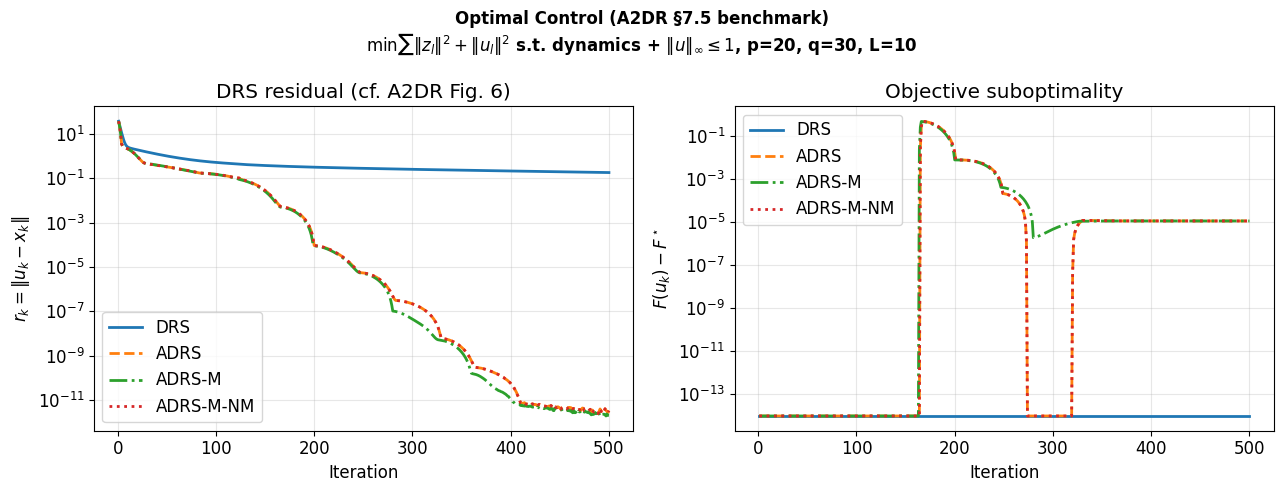

In [5]:
iters = np.arange(1, NITERS+1)
fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle(
    f'Optimal Control (A2DR §7.5 benchmark)\n'
    f'$\\min \\sum\\|z_l\\|^2+\\|u_l\\|^2$ s.t. dynamics + $\\|u\\|_\\infty\\leq 1$, '
    f'p={p}, q={q}, L={L}',
    fontsize=12, fontweight='bold')

for name,(r,o) in results.items():
    c,ls=COLORS[name],STYLES[name]
    axes[0].semilogy(iters, r, color=c, linestyle=ls, label=name)
    axes[1].semilogy(iters, np.maximum(o-F_STAR,1e-14), color=c, linestyle=ls, label=name)

axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('$r_k=\\|u_k-x_k\\|$')
axes[0].set_title('DRS residual (cf. A2DR Fig. 6)'); axes[0].legend()
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('$F(u_k)-F^\\star$')
axes[1].set_title('Objective suboptimality'); axes[1].legend()
plt.tight_layout(); plt.savefig('oc_main.png',dpi=130,bbox_inches='tight'); plt.show()

In [6]:
# Iterations to reach tolerance
tols = [1.0, 0.1, 0.01, 1e-3, 1e-4]
print(f'Strong convexity: both f1, f2 strongly convex with mu=1')
print(f'This is the regime where O(1/k^2) acceleration theory applies.\n')
print(f'{"Algorithm":<14}', end='')
for t in tols: print(f'  resid<{t:.0e}', end='')
print()
print('-'*65)
for name,(r,o) in results.items():
    print(f'{name:<14}', end='')
    for t in tols:
        h=next((i+1 for i,rv in enumerate(r) if rv<t),'N/A')
        print(f'  {str(h):>10}', end='')
    print()

Strong convexity: both f1, f2 strongly convex with mu=1
This is the regime where O(1/k^2) acceleration theory applies.

Algorithm       resid<1e+00  resid<1e-01  resid<1e-02  resid<1e-03  resid<1e-04
-----------------------------------------------------------------
DRS                     51         N/A         N/A         N/A         N/A
ADRS                    20         125         161         194         200
ADRS-M                  20         122         160         192         199
ADRS-M-NM               20         125         161         194         200
